# From RNN to LSTM — Solving the Vanishing Gradient

## Recap: What the RNN Cannot Do

The RNN processes sequences step by step and maintains a hidden state:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

During backpropagation through time (BPTT), the gradient of the loss with respect to an early hidden state $h_{t-k}$ involves a product of $k$ Jacobians:

$$\frac{\partial L}{\partial h_{t-k}} = \frac{\partial L}{\partial h_t} \cdot \prod_{i=0}^{k-1} \frac{\partial h_{t-i}}{\partial h_{t-i-1}}$$

Each term in this product is bounded by the spectral norm of $W_h$ multiplied by the derivative of $\tanh$. Since $|\tanh'| \leq 1$ everywhere, for long sequences this product shrinks exponentially — the network cannot learn dependencies beyond ~10–20 steps.

---

## The LSTM Solution — Gated Memory

The LSTM replaces the single hidden state with two: a **hidden state** $h_t$ and a **cell state** $c_t$. The cell state flows forward with only additive updates — no repeated multiplication — which allows gradients to flow unchanged across many steps.

Three learned gates control what information is kept, added, or exposed:

| Gate | Formula | Role |
|------|---------|------|
| Forget | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | How much of $c_{t-1}$ to erase |
| Input  | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | How much of the new candidate to write |
| Output | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | How much of the cell to expose as $h_t$ |

Cell and hidden state updates:

$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

When the forget gate is close to 1 and the input gate is close to 0, the cell state is copied almost unchanged — the gradient highway that prevents vanishing.

---

## Why This Matters for Volatility Forecasting

Volatility clustering in equity markets can persist for weeks or months. The LSTM's cell state is structurally capable of carrying a "high-volatility regime" signal across 50–100 time steps, whereas a vanilla RNN will forget it within 10–20 steps.

In [27]:
import torch
import sys
sys.path.append('src')
from data_utils import *
from dl_utils.Lstm import LSTM, Dense, Trainer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data

In [28]:
path_data = r"./data/df_sp_500_log_ret.csv"
df = pd.read_csv(path_data, index_col="Date")

X, y = build_dataset_abs_returns_sequential(df, 10)
X, y, scaler_x, scaler_y = scale_dataset_3d(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=80718)

In [29]:
X_train.shape

(5833, 10, 1)

## Model

In [30]:
INPUT_SIZE      = X_train.shape[2]
OUTPUT_SIZE     = y_train.shape[-1]
SEQUENCE_LENGTH = 10

HIDDEN_SIZE    = 32
NUM_LAYERS     = 1
DROPOUT        = 0.0
BIDIRECTIONAL  = False

nn_head_1 = Dense(
    HIDDEN_SIZE,
    OUTPUT_SIZE,
    activation   = 'none',   # identity — targets are standardized, ReLU would kill gradients
    dropout      = 0,
    bias         = True,
    weight_init  = 'xavier_uniform',
    bias_init    = 'zeros',
    batch_norm   = False,
)

lstm_model = LSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    lstm_dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    head=[nn_head_1],
)

LOSS             = 'mse'
OPTIMIZER        = "adam"
LR               = 0.001
BATCH_SIZE       = 32
N_EPOCH          = 100
SHUFFLE          = True
GRADIENT_CLIPPING = 1
EARLY_STOPPING   = 10
VERBOSE          = 10

trainer = Trainer(
    lstm_model,
    LOSS,
    OPTIMIZER,
    LR,
    BATCH_SIZE,
    N_EPOCH,
    SHUFFLE,
    GRADIENT_CLIPPING,
    EARLY_STOPPING,
    VERBOSE,
)
trainer.fit(X_train, y_train, X_test, y_test)

epoch    0  train: 0.861154  test: 0.739952
epoch   10  train: 0.695004  test: 0.712487
epoch   20  train: 0.686871  test: 0.706910
epoch   30  train: 0.672980  test: 0.699055
early stopping at epoch 40 — best test loss: 0.699055


## Training curves

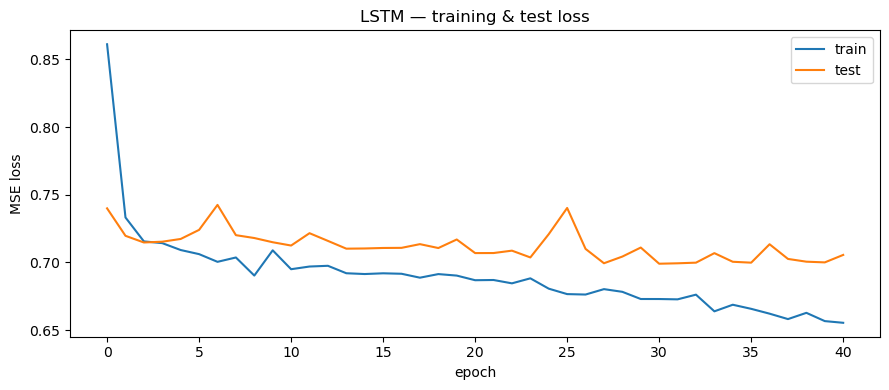

In [31]:
plt.figure(figsize=(9, 4))
plt.plot(trainer.train_losses, label='train')
plt.plot(trainer.test_losses,  label='test')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('LSTM — training & test loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [32]:
trainer.summary()

total parameters:     4513
trainable parameters: 4513
best train loss:      0.655422
best test loss:       0.699055


In [33]:
y_pred = trainer.predict(X_test, scaler_y=scaler_y)
y_true = scaler_y.inverse_transform(y_test)

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

MAE:  0.004970
RMSE: 0.007322


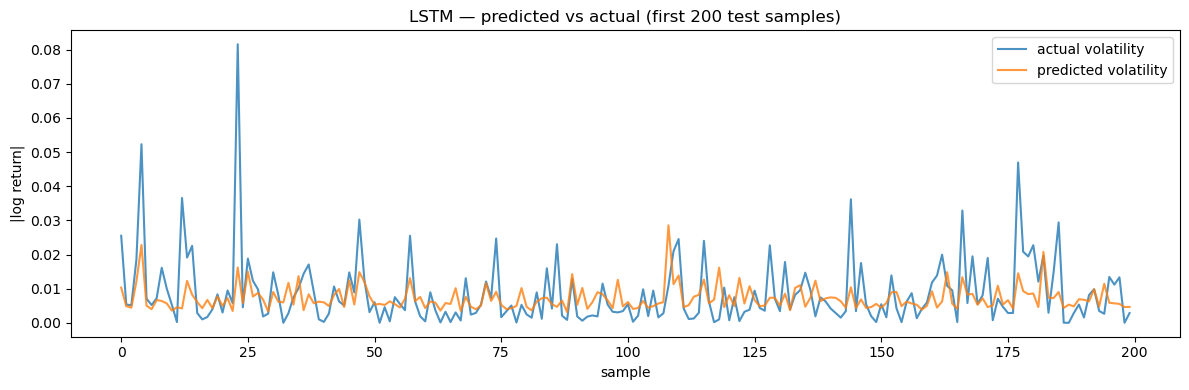

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(y_true[:200],  label='actual volatility',    alpha=0.8)
plt.plot(y_pred[:200],  label='predicted volatility', alpha=0.8)
plt.xlabel('sample')
plt.ylabel('|log return|')
plt.title('LSTM — predicted vs actual (first 200 test samples)')
plt.legend()
plt.tight_layout()
plt.show()

## Diagnosis — Why the Prediction is Constant

The model predicts approximately the **unconditional mean** of |log returns|. This is the MSE optimal solution when the model fails to explain variance:

$$\hat{y} = \bar{y} \implies \min_{\hat{y}} \mathbb{E}[(y - \hat{y})^2]$$

Volatility series have a highly skewed distribution: most returns are small, but occasional spikes are very large. MSE penalises those spikes so aggressively that the model learns "never predict a spike, just predict the mean" — a globally safe but useless strategy.

Two fixes:
1. **Switch to Huber / MAE loss** — both are less sensitive to large errors, so the model is no longer punished for deviating from the mean to chase spikes.
2. **Increase model capacity** — deeper head and larger hidden state so the LSTM can represent more complex temporal patterns.

In [35]:
# Sanity check: compare predicted range vs actual range
print(f"y_true  — mean: {y_true.mean():.5f}  std: {y_true.std():.5f}  min: {y_true.min():.5f}  max: {y_true.max():.5f}")
print(f"y_pred  — mean: {y_pred.mean():.5f}  std: {y_pred.std():.5f}  min: {y_pred.min():.5f}  max: {y_pred.max():.5f}")

y_true  — mean: 0.00768  std: 0.00840  min: 0.00000  max: 0.11052
y_pred  — mean: 0.00736  std: 0.00409  min: 0.00299  max: 0.05792


## Fixed Model — Huber loss + larger capacity

In [36]:
INPUT_SIZE      = X_train.shape[2]
OUTPUT_SIZE     = y_train.shape[-1]

HIDDEN_SIZE    = 64
NUM_LAYERS     = 2
DROPOUT        = 0.2
BIDIRECTIONAL  = False

head = [
    Dense(HIDDEN_SIZE, 32,          'relu', dropout=0.0, weight_init='xavier_uniform'),
    Dense(32,          OUTPUT_SIZE, 'none', dropout=0.0, weight_init='xavier_uniform'),  # identity output — no dead ReLU
]

lstm_model_v2 = LSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    lstm_dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    head=head,
)

trainer_v2 = Trainer(
    lstm_model_v2,
    loss_fn        = 'huber',
    optimizer      = 'adam',
    lr             = 0.001,
    batch_size     = 32,
    n_epochs       = 200,
    shuffle        = True,
    clip_grad_norm = 1.0,
    early_stopping = 15,
    verbose        = 20,
)
trainer_v2.fit(X_train, y_train, X_test, y_test)

epoch    0  train: 0.280039  test: 0.263933
epoch   20  train: 0.246890  test: 0.261032
early stopping at epoch 40 — best test loss: 0.255246


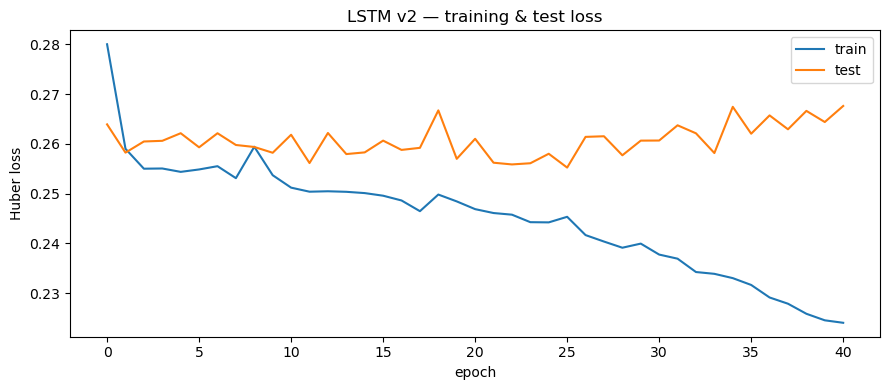

In [37]:
plt.figure(figsize=(9, 4))
plt.plot(trainer_v2.train_losses, label='train')
plt.plot(trainer_v2.test_losses,  label='test')
plt.xlabel('epoch')
plt.ylabel('Huber loss')
plt.title('LSTM v2 — training & test loss')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
y_pred_v2 = trainer_v2.predict(X_test, scaler_y=scaler_y)

mae_v2  = np.mean(np.abs(y_pred_v2 - y_true))
rmse_v2 = np.sqrt(np.mean((y_pred_v2 - y_true) ** 2))
print(f"MAE:  {mae_v2:.6f}  (was {mae:.6f})")
print(f"RMSE: {rmse_v2:.6f}  (was {rmse:.6f})")
print()
print(f"y_pred_v2 — mean: {y_pred_v2.mean():.5f}  std: {y_pred_v2.std():.5f}  min: {y_pred_v2.min():.5f}  max: {y_pred_v2.max():.5f}")

MAE:  0.004857  (was 0.004970)
RMSE: 0.007403  (was 0.007322)

y_pred_v2 — mean: 0.00658  std: 0.00368  min: 0.00314  max: 0.05959


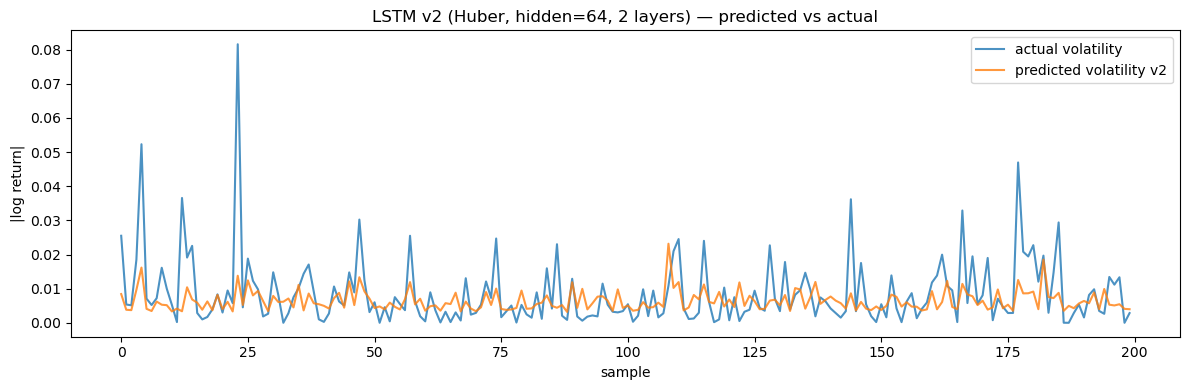

In [39]:
plt.figure(figsize=(12, 4))
plt.plot(y_true[:200],    label='actual volatility',       alpha=0.8)
plt.plot(y_pred_v2[:200], label='predicted volatility v2', alpha=0.8)
plt.xlabel('sample')
plt.ylabel('|log return|')
plt.title('LSTM v2 (Huber, hidden=64, 2 layers) — predicted vs actual')
plt.legend()
plt.tight_layout()
plt.show()

## Comparison — LSTM v1 vs LSTM v2

In [40]:
# Metrics table
print(f"{'Model':<30} {'MAE':>10} {'RMSE':>10} {'Pred std':>10}")
print("-" * 62)
print(f"{'v1  (MSE,    hidden=32, 1L)':<30} {mae:>10.6f} {rmse:>10.6f} {y_pred.std():>10.6f}")
print(f"{'v2  (Huber,  hidden=64, 2L)':<30} {mae_v2:>10.6f} {rmse_v2:>10.6f} {y_pred_v2.std():>10.6f}")
print()
print(f"Actual std: {y_true.std():.6f}")

Model                                 MAE       RMSE   Pred std
--------------------------------------------------------------
v1  (MSE,    hidden=32, 1L)      0.004970   0.007322   0.004092
v2  (Huber,  hidden=64, 2L)      0.004857   0.007403   0.003682

Actual std: 0.008402


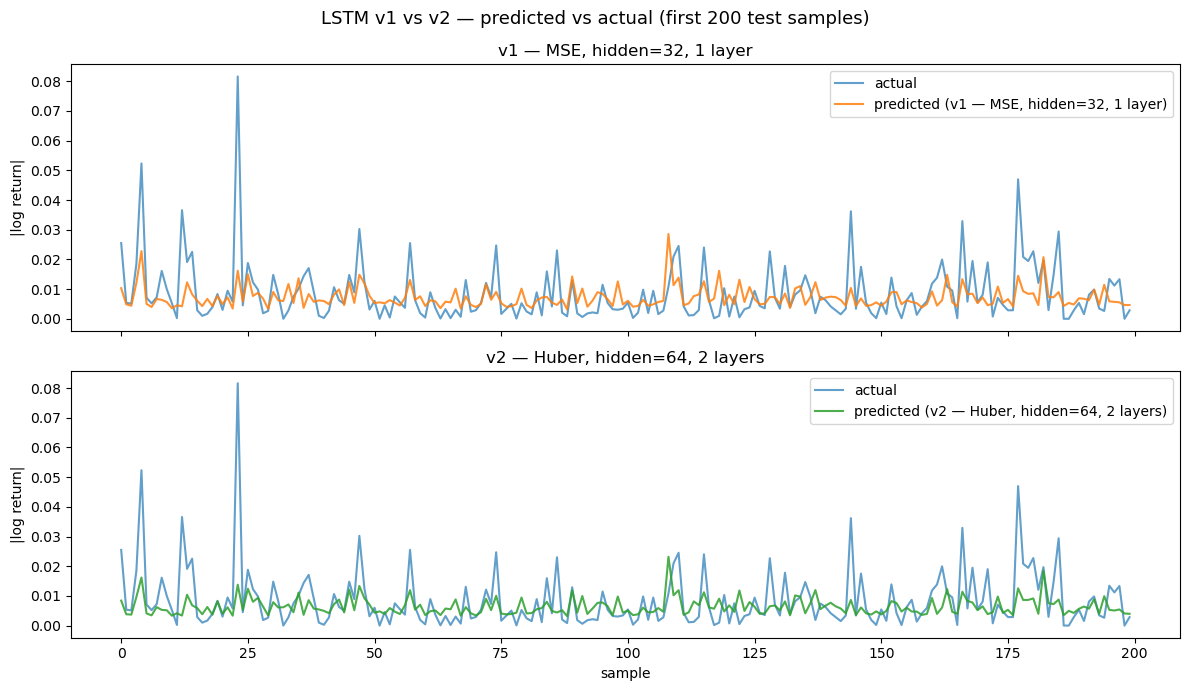

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)

for ax, y_p, label, color in zip(
    axes,
    [y_pred, y_pred_v2],
    ['v1 — MSE, hidden=32, 1 layer', 'v2 — Huber, hidden=64, 2 layers'],
    ['tab:orange', 'tab:green'],
):
    ax.plot(y_true[:200], label='actual', alpha=0.7, color='tab:blue')
    ax.plot(y_p[:200],    label=f'predicted ({label})', alpha=0.85, color=color)
    ax.set_ylabel('|log return|')
    ax.set_title(label)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('sample')
plt.suptitle('LSTM v1 vs v2 — predicted vs actual (first 200 test samples)', fontsize=13)
plt.tight_layout()
plt.show()

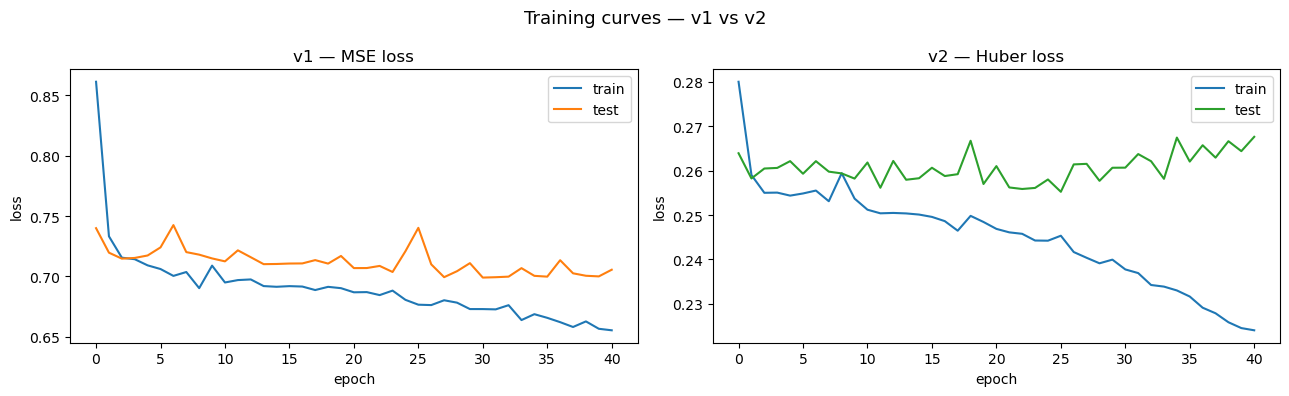

In [42]:
# Loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(trainer.train_losses,    label='train', color='tab:blue')
axes[0].plot(trainer.test_losses,     label='test',  color='tab:orange')
axes[0].set_title('v1 — MSE loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].plot(trainer_v2.train_losses, label='train', color='tab:blue')
axes[1].plot(trainer_v2.test_losses,  label='test',  color='tab:green')
axes[1].set_title('v2 — Huber loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend()

plt.suptitle('Training curves — v1 vs v2', fontsize=13)
plt.tight_layout()
plt.show()

### Analysis — Why train loss keeps falling while test loss plateaus

Both models show the same pattern: **training loss decreases steadily while test loss stagnates or diverges**. This is textbook overfitting, but the cause in this setting is specific.

#### v1 — MSE (left panel)
Train falls from ~0.85 → ~0.65. Test drops quickly for the first ~5 epochs then plateaus around 0.70. The model learns the broad structure of the data fast, then spends the remaining epochs fitting noise in the training set that has no equivalent in the test set.

#### v2 — Huber (right panel)
The same dynamic, more clearly visible. Train decreases steadily from ~0.28 → ~0.23 across 40 epochs. Test starts at ~0.26, oscillates, and ends slightly *higher* than where it started — the model is actively getting worse on unseen data while improving on training data.

#### Why this happens here

**1. Financial returns are close to i.i.d.**  
Log returns have very weak serial autocorrelation. The LSTM can learn the unconditional distribution (mean, variance) in a few epochs. After that, there is no more genuine signal — any further loss reduction on the training set comes from memorising specific sequences of dates, not from learning transferable dynamics.

**2. The model has more capacity than the signal justifies**  
v2 has 64 hidden units × 2 layers ≈ ~50k parameters trained on a few thousand windows. With this ratio, the model can interpolate the training set without generalising.

**3. Dropout only affects training**  
The 0.2 dropout applied in v2 regularises training but is disabled at test time. This creates a structural gap: the effective model at test time is a larger, deterministic ensemble of the trained sub-networks — which is more prone to memorisation artefacts showing up in the train/test gap.

#### What to try next

| Fix | Rationale |
|-----|-----------|
| Increase dropout (0.3–0.5) | Forces more redundancy in representations |
| Add weight decay (`Adam(weight_decay=1e-4)`) | L2 penalty directly discourages memorisation |
| Reduce hidden size or layers | Fewer parameters → less room to memorise |
| Increase sequence length (20–30) | Gives the LSTM more temporal context; may expose real clustering signal |